In [1]:
# ===========================================================================
# UA-SPEECH DATA PIPELINE - interactive driver
#
# All logic lives in the src/ package; this notebook only calls it, so the
# notebook and run_pipeline.py cannot drift apart. To change behaviour, edit
# the module, not this notebook.
#
#   src/config.py         paths, speaker ground truth, label maps, hyperparams
#   src/extraction.py     .tgz archive extraction
#   src/scanning.py       filename parsing, verification, mic filter, labels
#   src/visualization.py  EDA figures
#   src/splits.py         LOSO (detection) and balanced 81-fold (severity)
#   src/preprocessing.py  resample, VAD trim, pad, MFCC
#   src/dataset.py        UASpeechDataset
#   src/models/           deep / acoustic / fusion pathways
# ===========================================================================

# STAGE 0 - Setup. Put the project root on the import path; autoreload picks up
# edits to src/ without a kernel restart.
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.console import print_header, print_kv

config.ensure_directories()

print_header("UA-Speech Dysarthria Pipeline")
print_kv("Project root", config.PROJECT_ROOT)
print_kv("Archive folder", config.ARCHIVE_DIR)
print_kv("Audio folder", config.AUDIO_DIR)
print_kv("Ground truth", f"{len(config.CONTROL_IDS)} controls + "
                        f"{len(config.DYSARTHRIC_IDS)} dysarthric = "
                        f"{len(config.ALL_SPEAKERS)} speakers")
print_kv("Microphone channel", config.TARGET_MIC)
print_kv("Words per speaker", config.WORDS_PER_SPEAKER)


══════════════════════════════════════════════════════════════════════════════
  UA-SPEECH DYSARTHRIA PIPELINE
══════════════════════════════════════════════════════════════════════════════
  Project root ............................ C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification
  Archive folder .......................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\data\archives
  Audio folder ............................ C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\data\extracted
  Ground truth ............................ 13 controls + 15 dysarthric = 28 speakers
  Microphone channel ...................... M6
  Words per speaker ....................... 765


In [2]:
# STAGE 1 - Extract the archives.
# Copy UASpeech_normalized_C.tgz and UASpeech_normalized_FM.tgz into
# data/archives/ first. Runs once; the extracted audio persists in
# data/extracted/, so skip this cell on later passes.
from src.extraction import extract_all_archives

extract_all_archives()


══════════════════════════════════════════════════════════════════════════════
  DATASET EXTRACTION
══════════════════════════════════════════════════════════════════════════════
  Archive folder .......................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\data\archives
  Extract folder .......................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\data\extracted
  Extracting .............................. UASpeech_normalized_C.tgz
  [ ✓ ] Extracted UASpeech_normalized_C.tgz
  Extracting .............................. UASpeech_normalized_FM.tgz
  [ ✓ ] Extracted UASpeech_normalized_FM.tgz
  Archives extracted ...................... 2 / 2


2

In [3]:
# STAGE 2 - Scan and verify against the 28-speaker ground truth.
# Filenames parse as <Speaker>_<Block>_<WordCode>_<Mic>.wav. Two rules baked
# into parse_filename, both of which the original exploratory scan got wrong:
#   1. The mic channel is taken POSITIONALLY from the final token. The old
#      logic searched for the first token starting with 'M', which matched male
#      speaker IDs like M01 before ever reaching the real mic token.
#   2. macOS resource-fork duplicates ('._' prefix) are skipped - the archive
#      holds one per real .wav, which doubled the apparent file count.
from src.scanning import scan_audio_files, verify_speakers

df_audio = scan_audio_files()
speakers_ok = verify_speakers(df_audio)

df_audio.head()


══════════════════════════════════════════════════════════════════════════════
  DATASET SCAN
══════════════════════════════════════════════════════════════════════════════
  Scanning folder ......................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\data\extracted
  Valid audio files ....................... 143565
  Skipped files ........................... 143565
  Unique speakers ......................... 28

─── Speaker Verification ─────────────────────────────────────────────────────
  Expected speakers ....................... 28
  Found speakers .......................... 28
  Missing ................................. None
  Spurious ................................ None
  [ ✓ ] All 28 ground-truth speakers present, no spurious IDs


,Filename,Speaker_ID,Group,Block,WordCode,Microphone_Channel,Filepath
0,CF02_B1_C10_M2.wav,CF02,Healthy Control,B1,C10,M2,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...
1,CF02_B1_C10_M3.wav,CF02,Healthy Control,B1,C10,M3,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...
2,CF02_B1_C10_M4.wav,CF02,Healthy Control,B1,C10,M4,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...
3,CF02_B1_C10_M5.wav,CF02,Healthy Control,B1,C10,M5,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...
4,CF02_B1_C10_M6.wav,CF02,Healthy Control,B1,C10,M6,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...



══════════════════════════════════════════════════════════════════════════════
  EXPLORATORY DATA ANALYSIS
══════════════════════════════════════════════════════════════════════════════


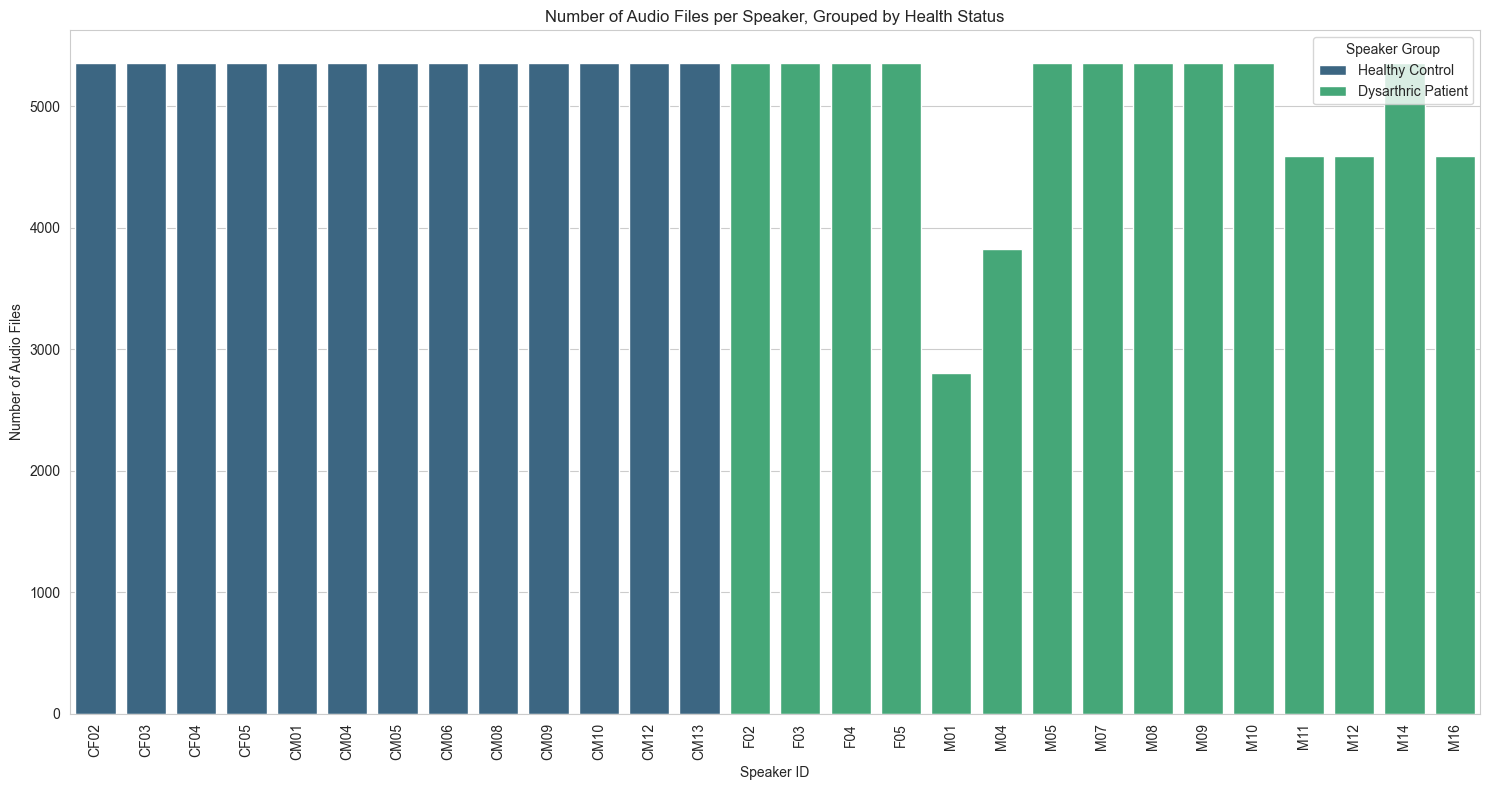

  Files-per-speaker plot .................. C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\figures\files_per_speaker.png


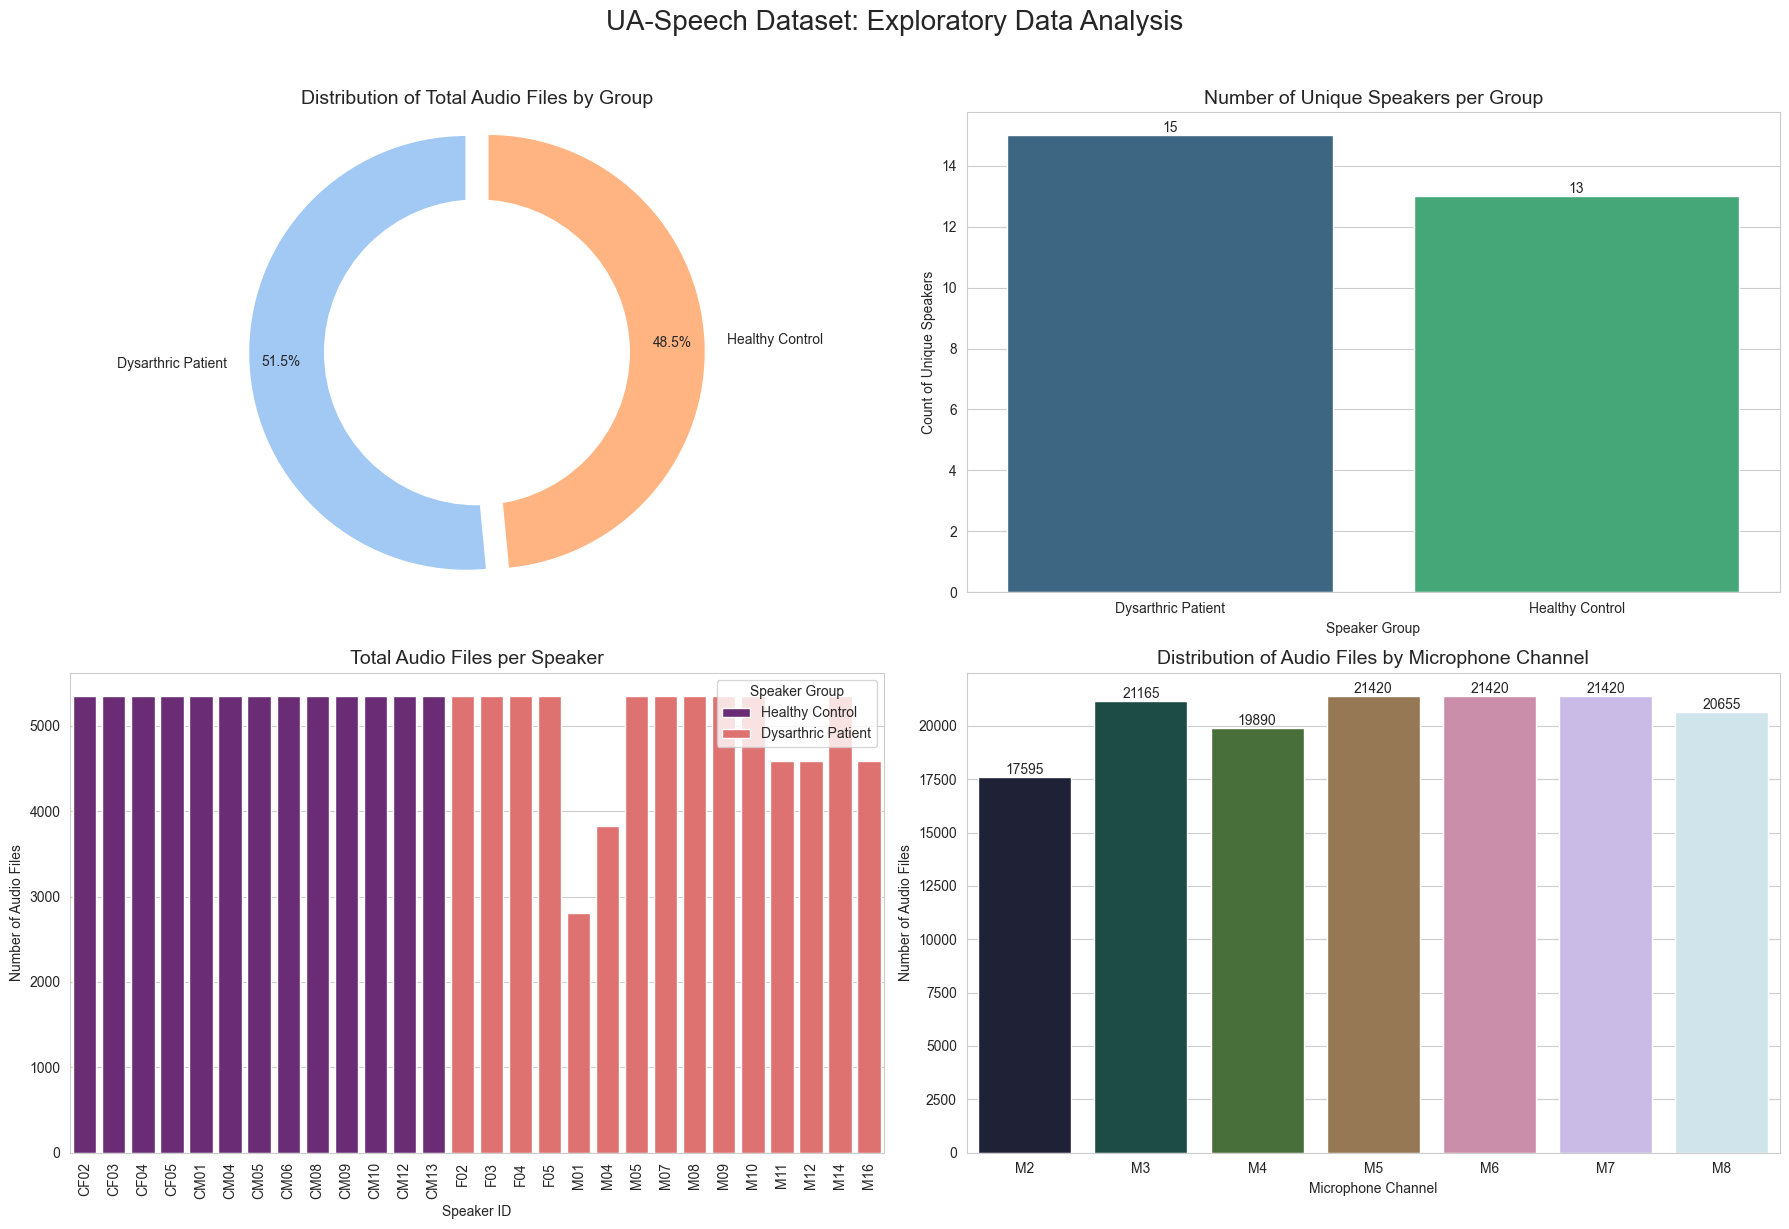

  Dataset dashboard ....................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\figures\uaspeech_dashboard.png


In [4]:
# STAGE 3 - EDA. Figures render inline and are also saved to outputs/figures/
# at 300 dpi, ready for the IEEE paper draft.
from src.visualization import run_eda

run_eda(df_audio, show=True)

In [5]:
# STAGE 4 - Filter to microphone channel M6 (base-paper protocol: M6 only, all
# three blocks, all word categories, no word-type filtering).
# Expect 21,420 utterances: 11,475 dysarthric + 9,945 healthy control.
from src.scanning import filter_mic_channel

df_m6 = filter_mic_channel(df_audio)


─── Microphone Filter (M6 only) ──────────────────────────────────────────────
  Total M6 samples ........................ 21420
    Dysarthric Patient .................... 11475
    Healthy Control ....................... 9945
  Missing dysarthric speakers on M6 ....... None
  Missing control speakers on M6 .......... None


In [6]:
# STAGE 5 - Validate WAV headers. A handful of UA-Speech files extracted
# zero-filled (see README "Data verification note") - torchaudio/libsndfile
# can't read them, and they would otherwise crash training partway through a
# LOSO run. Dropped here, before word counts, so the count check reflects
# genuinely usable data.
from src.scanning import validate_wav_headers

df_m6 = validate_wav_headers(df_m6)



─── WAV Header Validation ────────────────────────────────────────────────────
  Files checked ........................... 21420
  Corrupted (dropped) ..................... 39
  Speaker_ID
  F03    24
  F04    15
  [ ✗ ] 39 corrupted file(s) excluded from the manifest - see the dropped rows' Speaker_ID/WordCode above


In [7]:
# STAGE 6 - Per-speaker word counts; every speaker should have all 765 words on
# M6. Speakers below that are flagged, NOT dropped: an incomplete speaker is
# still usable, and silently removing one would change the LOSO fold count.
from src.scanning import check_word_counts

word_counts = check_word_counts(df_m6)


─── Per-Speaker Word Counts (target: 765) ────────────────────────────────────
  Speaker_ID
  F03     741
  F04     750
  CF02    765
  CF03    765
  CM01    765
  CM04    765
  CF04    765
  CF05    765
  CM06    765
  CM05    765
  CM08    765
  CM09    765
  CM12    765
  CM10    765
  F02     765
  CM13    765
  F05     765
  M01     765
  M04     765
  M05     765
  M07     765
  M08     765
  M09     765
  M10     765
  M11     765
  M12     765
  M14     765
  M16     765
  [ ✗ ] 2 speaker(s) below 765 words (flag, don't drop)
  Speaker_ID
  F03    741
  F04    750


In [8]:
# STAGE 7 - Severity labels: four classes (Very Low / Low / Mid / High) for the
# 15 dysarthric speakers; controls get 'N/A (Control)'.
from src.scanning import add_severity_labels

df_m6 = add_severity_labels(df_m6)

df_m6.head()


─── Severity Labels ──────────────────────────────────────────────────────────
  [ ✓ ] No unmapped dysarthric speakers
  Severity
  N/A (Control)    9945
  High             3825
  Very Low         3036
  Low              2295
  Mid              2280


,Filename,Speaker_ID,Group,Block,WordCode,Microphone_Channel,Filepath,Severity
4,CF02_B1_C10_M6.wav,CF02,Healthy Control,B1,C10,M6,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...,N/A (Control)
11,CF02_B1_C11_M6.wav,CF02,Healthy Control,B1,C11,M6,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...,N/A (Control)
18,CF02_B1_C12_M6.wav,CF02,Healthy Control,B1,C12,M6,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...,N/A (Control)
25,CF02_B1_C13_M6.wav,CF02,Healthy Control,B1,C13,M6,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...,N/A (Control)
32,CF02_B1_C14_M6.wav,CF02,Healthy Control,B1,C14,M6,C:\Users\surya\OneDrive\Desktop\Acoustic-Aware...,N/A (Control)


In [9]:
# STAGE 8 - Cross-validation splits.
#   Detection: Leave-One-Speaker-Out over all 28 speakers -> 28 folds.
#   Severity:  classes are unbalanced (4/3/3/5 speakers), so
#              config.DROPPED_FOR_BALANCE excludes M12, M08, F05 to reach 3 per
#              class -> 3^4 = 81 leave-one-per-class-out iterations.
#
# NOTE: the base paper gives no explicit exclusion list, so that set of three
# speakers is OUR ASSUMPTION. Confirm with the team before treating any
# severity result as final.
from src.splits import build_severity_folds, get_loso_split, summarize_detection_splits

summarize_detection_splits(df_m6)
severity_folds = build_severity_folds(df_m6)


══════════════════════════════════════════════════════════════════════════════
  DETECTION SPLITS (LEAVE-ONE-SPEAKER-OUT)
══════════════════════════════════════════════════════════════════════════════
  Total LOSO folds ........................ 28

─── Example fold (CF02 held out) ─────────────────────────────────────────────
  Train samples ........................... 20616
  Test samples ............................ 765

══════════════════════════════════════════════════════════════════════════════
  SEVERITY SPLITS (BALANCED LEAVE-ONE-PER-CLASS-OUT)
══════════════════════════════════════════════════════════════════════════════
  Speakers dropped for balance ............ ['M12', 'M08', 'M09']

─── Speakers per severity class ──────────────────────────────────────────────
  High .................................... F05, M10, M14
  Low ..................................... F02, M07, M16
  Mid ..................................... F04, M05, M11
  Very Low ..............................

In [10]:
# STAGE 9 - Build the PyTorch dataset. UASpeechDataset returns the raw waveform
# (Deep Pathway), the 39-dim MFCC tensor (Acoustic Pathway), both labels, and
# the speaker ID - so both pathways train on identical audio and splits.
from src.dataset import UASpeechDataset

dataset = UASpeechDataset(df_m6)
sample = dataset[0]

print_header("Dataset Build")
print_kv("Total samples", len(dataset))
print_kv("Waveform shape", tuple(sample["waveform"].shape))
print_kv("MFCC shape", tuple(sample["mfcc"].shape))
print_kv("Detection label", sample["group_label"].item())
print_kv("Severity label", sample["severity_label"].item())
print_kv("Speaker ID", sample["speaker_id"])

manifest_path = config.OUTPUT_DIR / "m6_manifest.csv"
df_m6.to_csv(manifest_path, index=False)
print_kv("Manifest saved", manifest_path)


══════════════════════════════════════════════════════════════════════════════
  DATASET BUILD
══════════════════════════════════════════════════════════════════════════════
  Total samples ........................... 21381
  Waveform shape .......................... (1, 64000)
  MFCC shape .............................. (1, 39, 401)
  Detection label ......................... 0
  Severity label .......................... -1
  Speaker ID .............................. CF02
  Manifest saved .......................... C:\Users\surya\OneDrive\Desktop\Acoustic-Aware-Fusion-Architecture-for-Dysarthria-Classification\outputs\m6_manifest.csv


In [11]:
# STAGE 10 - Fusion model shape check. One forward pass to confirm the pathways
# line up: Deep 768 + Acoustic 128 -> classifier consumes 896.
# Downloads the wav2vec 2.0 weights on first run.
# Architecture check only - training is the Fusion Architect's task, not built.
import torch
from torch.utils.data import DataLoader

from src.models.concat_fusion import FusionModel

loader = DataLoader(dataset, batch_size=2, shuffle=True)
batch = next(iter(loader))

model = FusionModel(num_classes=2)  # 2 = detection task; use 4 for severity
model.eval()

with torch.no_grad():
    logits = model(batch["waveform"].squeeze(1), batch["mfcc"])

print_header("Fusion Model Shape Check")
print_kv("Waveform batch", tuple(batch["waveform"].squeeze(1).shape))
print_kv("MFCC batch", tuple(batch["mfcc"].shape))
print_kv("Output logits", tuple(logits.shape))
print_kv("LoRA parameters", model.deep_pathway.trainable_parameter_summary())

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



══════════════════════════════════════════════════════════════════════════════
  FUSION MODEL SHAPE CHECK
══════════════════════════════════════════════════════════════════════════════
  Waveform batch .......................... (2, 64000)
  MFCC batch .............................. (2, 1, 39, 401)
  Output logits ........................... (2, 2)
  LoRA parameters ......................... trainable: 442,368 / total: 94,814,080 (0.47%)
